In [1]:
import pandas as pd
import numpy as np

days = 100
data = {
    "day": np.arange(days),
    "soil_moisture": np.random.uniform(20, 60, days),
    "temperature": np.random.uniform(15, 35, days),
    "humidity": np.random.uniform(40, 80, days),
    "rainfall": np.random.uniform(0, 20, days),
    "yield": np.random.uniform(100, 300, days)  # synthetic yield
}
df = pd.DataFrame(data)
df.head()


,day,soil_moisture,temperature,humidity,rainfall,yield
0,0,27.547408,15.823765,54.683424,13.457028,124.813179
1,1,53.591954,15.678442,41.868587,8.384780,148.109581
2,2,45.559074,23.414407,43.164133,3.163932,226.814950
3,3,44.296613,31.783453,53.661508,0.228601,204.197359
4,4,53.302395,22.047251,79.981485,18.686586,270.987863


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df[["soil_moisture", "temperature", "humidity", "rainfall"]]
y = df["yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("R^2:", r2_score(y_test, preds))


R^2: -0.33894118002844875


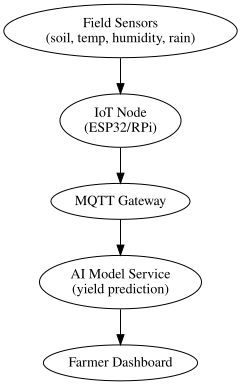

In [4]:
!pip install graphviz
from graphviz import Digraph

dot = Digraph()
dot.node("Sensors", "Field Sensors\n(soil, temp, humidity, rain)")
dot.node("IoT", "IoT Node\n(ESP32/RPi)")
dot.node("Gateway", "MQTT Gateway")
dot.node("AI", "AI Model Service\n(yield prediction)")
dot.node("Dashboard", "Farmer Dashboard")

# Correct way: use tuples for edges
dot.edges([
    ("Sensors", "IoT"),
    ("IoT", "Gateway"),
    ("Gateway", "AI"),
    ("AI", "Dashboard")
])

dot.render("iot_flow", format="png")
dot
